### Merge ISPU Data and Formating

In [120]:
import pandas as pd
import os
import re

# CONFIG
FOLDER_PATH = "data/ISPU"
OUTPUT_PATH = "data/ISPU/ispu_dki_2010_2025.csv"

FILES_WITH_YEAR = {
    "data-indeks-standar-pencemar-udara-(ispu)-di-provinsi-dki-jakarta-komponen-data-2024.csv": 2024,
    "data-indeks-standar-pencemar-udara-(ispu)-di-provinsi-dki-jakarta-komponen-data-2025.csv": 2025,
}

COLUMN_MAPPING = {
    "lokasi_spku": "stasiun",

    "pm_sepuluh": "pm10",
    "pm_10": "pm10",

    "pm_duakomalima": "pm2.5",
    "pm25": "pm2.5",

    "sulfur_dioksida": "so2",
    "nitrogen_dioksida": "no2",
    "karbon_monoksida": "co",
    "ozon": "o3",

    "categori": "kategori",
    "parameter_pencemar_kritis": "critical"
}

REQUIRED_COLUMNS = ["pm10", "pm2.5", "so2", "no2", "co", "o3"]

# HELPERS
def clean_tanggal(x):
    if pd.isna(x):
        return pd.NaT

    try:
        x = float(x)
        if x > 30000:
            return pd.to_datetime(x, unit="D", origin="1899-12-30")
    except:
        pass

    return pd.to_datetime(x, dayfirst=True, errors="coerce")


def clean_stasiun(x):
    if pd.isna(x):
        return pd.NA

    x = str(x).upper().strip()

    match = re.search(r"DKI\s*([1-5])", x)
    if match:
        return f"DKI{match.group(1)}"

    return pd.NA

def clean_missing_symbols(df: pd.DataFrame, exclude_cols=None):
    if exclude_cols is None:
        exclude_cols = []

    for col in df.columns:
        if col in exclude_cols:
            continue

        df[col] = df[col].replace(
            to_replace=r"^\s*-+\s*$",  
            value=pd.NA,
            regex=True
        )

    return df

def process_ispu(df: pd.DataFrame, year: int | None = None) -> pd.DataFrame:
    df = df.copy()

    df.columns = df.columns.str.lower().str.strip()
    df.rename(columns=COLUMN_MAPPING, inplace=True)

    if {"bulan", "tanggal"}.issubset(df.columns) and year is not None:
        df["year"] = year
        df.rename(columns={"bulan": "month", "tanggal": "day"}, inplace=True)

        df["tanggal"] = pd.to_datetime(
            df[["year", "month", "day"]],
            errors="coerce"
        )

        df.drop(columns=["year", "month", "day"], inplace=True)

    if "tanggal" in df.columns:
        df["tanggal"] = (
            df["tanggal"]
            .apply(clean_tanggal)
            .dt.date
        )

    df = clean_missing_symbols(df, exclude_cols=["tanggal"])

    for col in REQUIRED_COLUMNS:
        if col not in df.columns:
            df[col] = pd.NA
        df[col] = pd.to_numeric(df[col], errors="coerce")

    if "stasiun" in df.columns:
        df["stasiun"] = df["stasiun"].apply(clean_stasiun)

    return df

# MAIN PIPELINE
dfs = []

for file in os.listdir(FOLDER_PATH):
    if not file.endswith(".csv"):
        continue
    if file == os.path.basename(OUTPUT_PATH):
        continue  

    path = os.path.join(FOLDER_PATH, file)
    df_raw = pd.read_csv(path)

    year = FILES_WITH_YEAR.get(file)  
    df_clean = process_ispu(df_raw, year)
    dfs.append(df_clean)


# concat semua
df_all = pd.concat(dfs, ignore_index=True)

df_all["tanggal"] = pd.to_datetime(df_all["tanggal"], errors="coerce")

df_all = (
    df_all
    .sort_values(["tanggal", "stasiun"])
    .reset_index(drop=True)
)

df_all.to_csv(OUTPUT_PATH, index=False)

print("Selesai Merge ISPU")


C:\Users\rovan wardana\AppData\Local\Temp\ipykernel_27024\435422656.py:46: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  return pd.to_datetime(x, dayfirst=True, errors="coerce")
C:\Users\rovan wardana\AppData\Local\Temp\ipykernel_27024\435422656.py:46: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  return pd.to_datetime(x, dayfirst=True, errors="coerce")
C:\Users\rovan wardana\AppData\Local\Temp\ipykernel_27024\435422656.py:46: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  return pd.to_datetime(x, dayfirst=True, errors="coerce")
C:\Users\rovan wardana\AppData\Local\Temp\ipykernel_27024\435422656.py:46: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pa

Selesai Merge ISPU


### Merge Cuaca

In [121]:
from pathlib import Path

data_cuaca_path = Path("data/cuaca-harian")

dfs = []

for file_path in data_cuaca_path.glob("cuaca-harian-dki[1-5]-*.csv"):
    filename = file_path.stem
    stasiun = filename.split("-")[2].strip().upper()  # DKI1–DKI5

    df = pd.read_csv(file_path)

    # ubah nama kolom time -> tanggal
    df = df.rename(columns={"time": "tanggal"})

    # pastikan tanggal bertipe datetime
    df['tanggal'] = pd.to_datetime(df['tanggal'], errors='coerce')

    df['stasiun'] = stasiun
    dfs.append(df)

if not dfs:
    raise ValueError("Tidak ada file DKI1–DKI5 yang terbaca")

df_cuaca_all = pd.concat(dfs, ignore_index=True)

# sorting
stasiun_order = ['DKI1','DKI2','DKI3','DKI4','DKI5']
df_cuaca_all['stasiun'] = pd.Categorical(
    df_cuaca_all['stasiun'],
    categories=stasiun_order,
    ordered=True
)

df_cuaca_all = (
    df_cuaca_all
    .sort_values(['tanggal', 'stasiun'])
    .reset_index(drop=True)
)

output_path = data_cuaca_path / "cuaca-harian-dki-gabungan.csv"
df_cuaca_all.to_csv(output_path, index=False)

print("Selesai. File tersimpan di:", output_path)


Selesai. File tersimpan di: data\cuaca-harian\cuaca-harian-dki-gabungan.csv


### Perbaikan sorted NDVI

In [122]:
df = pd.read_csv("data/NDVI (vegetation index)/indeks-ndvi-jakarta.csv")  

df["tanggal"] = pd.to_datetime(df["tanggal"])

df = df.sort_values(by=["tanggal", "stasiun_id"])

df = df.reset_index(drop=True)

df = df.rename(columns={"stasiun_id": "stasiun"})

df.to_csv("data/NDVI (vegetation index)/ndvi_sorted.csv", index=False)

## Merge data penduduk

In [123]:
data_penduduk_dir = Path("data/jumlah-penduduk")
output_file = data_penduduk_dir / "data_penduduk.csv"

mapping_stasiun = {
    "Jakarta Pusat": "DKI1",
    "Jakarta Utara": "DKI2",
    "Jakarta Selatan": "DKI3",
    "Jakarta Timur": "DKI4",
    "Jakarta Barat": "DKI5",
}

dfs = []

for file_path in data_penduduk_dir.glob("*.csv"):
    if file_path.name == output_file.name:
        continue

    try:
        tahun = int(file_path.stem)
    except ValueError:
        continue

    df = pd.read_csv(file_path, header=None)

    df = df.iloc[:, :2]
    df.columns = ["wilayah", "jumlah_penduduk"]

    df = df.dropna()
    df = df[~df["wilayah"].astype(str).str.contains("kab/kota|0", case=False)]

    df["jumlah_penduduk"] = pd.to_numeric(df["jumlah_penduduk"], errors="coerce")

    df = df[df["wilayah"].isin(mapping_stasiun.keys())]

    df["stasiun"] = df["wilayah"].map(mapping_stasiun)
    df["tahun"] = tahun

    dfs.append(df[["stasiun", "tahun", "jumlah_penduduk"]])

df_penduduk = (
    pd.concat(dfs, ignore_index=True)
      .sort_values(["stasiun", "tahun"])
      .reset_index(drop=True)
)

df_penduduk.to_csv(output_file, index=False, encoding="utf-8")
print(f"Berhasil disimpan di: {output_file}")


Berhasil disimpan di: data\jumlah-penduduk\data_penduduk.csv


### MERGE ISPU, CUACA HARIAN DAN NDVI

In [124]:
BASE_DIR = Path("data")

df_ispu = pd.read_csv(BASE_DIR / "ISPU" / "ispu_dki_2010_2025.csv")
df_cuaca = pd.read_csv(BASE_DIR / "cuaca-harian" / "cuaca-harian-dki-gabungan.csv")
df_ndvi = pd.read_csv(BASE_DIR / "NDVI (vegetation index)" / "ndvi_sorted.csv")
df_libur = pd.read_csv(BASE_DIR / "libur-nasional" / "dataset-libur-nasional-dan-weekend.csv")
df_penduduk = pd.read_csv(BASE_DIR / "jumlah-penduduk" / "data_penduduk.csv")

for df in [df_ispu, df_cuaca, df_ndvi]:
    df["tanggal"] = pd.to_datetime(df["tanggal"])

df_libur["tanggal"] = pd.to_datetime(df_libur["tanggal"])

df_ispu = df_ispu.sort_values(["tanggal", "stasiun"])
df_cuaca = df_cuaca.sort_values(["tanggal", "stasiun"])
df_ndvi = df_ndvi.sort_values(["tanggal", "stasiun"])

df_merge = pd.merge(
    df_ispu,
    df_cuaca,
    on=["tanggal", "stasiun"],
    how="inner"
)

df_merge = pd.merge(
    df_merge,
    df_ndvi,
    on=["tanggal", "stasiun"],
    how="left"
)

df_merge = pd.merge(
    df_merge,
    df_libur,
    on="tanggal",
    how="left"
)

# ambil tahun dari tanggal
df_merge["tahun"] = df_merge["tanggal"].dt.year

df_merge = pd.merge(
    df_merge,
    df_penduduk,
    on=["stasiun", "tahun"],
    how="left"
)

# isi missing penduduk
df_merge = df_merge.sort_values(["stasiun", "tanggal"])

df_merge["jumlah_penduduk"] = (
    df_merge
    .groupby("stasiun")["jumlah_penduduk"]
    .ffill()
    .bfill()
)

df_merge = df_merge.reset_index(drop=True)

if "kategori" in df_merge.columns:
    kolom = [c for c in df_merge.columns if c != "kategori"] + ["kategori"]
    df_merge = df_merge[kolom]

output_path = BASE_DIR / "merged_data.csv"
df_merge.to_csv(output_path, index=False)

print(f"File berhasil disimpan di: {output_path}")


File berhasil disimpan di: data\merged_data.csv


# EDA (Exploratory Data Analysis)

In [125]:
# Library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [126]:
df = pd.read_csv("data/merged_data.csv")

C:\Users\rovan wardana\AppData\Local\Temp\ipykernel_27024\4247355878.py:1: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/merged_data.csv")


In [127]:
date_col = "tanggal"   
entity_col = "stasiun"
target_col = "kategori"

num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
print("Numerik:", num_cols)
print("Kategori:", cat_cols)

Numerik: ['periode_data', 'pm10', 'pm2.5', 'so2', 'co', 'o3', 'no2', 'temperature_2m_max (°C)', 'temperature_2m_min (°C)', 'precipitation_sum (mm)', 'precipitation_hours (h)', 'wind_speed_10m_max (km/h)', 'wind_direction_10m_dominant (°)', 'shortwave_radiation_sum (MJ/m²)', 'temperature_2m_mean (°C)', 'relative_humidity_2m_mean (%)', 'cloud_cover_mean (%)', 'surface_pressure_mean (hPa)', 'wind_gusts_10m_max (km/h)', 'winddirection_10m_dominant (°)', 'relative_humidity_2m_max (%)', 'relative_humidity_2m_min (%)', 'cloud_cover_max (%)', 'cloud_cover_min (%)', 'wind_gusts_10m_mean (km/h)', 'wind_speed_10m_mean (km/h)', 'wind_gusts_10m_min (km/h)', 'wind_speed_10m_min (km/h)', 'surface_pressure_max (hPa)', 'surface_pressure_min (hPa)', 'ndvi', 'is_holiday_nasional', 'is_weekend', 'tahun', 'jumlah_penduduk']
Kategori: ['tanggal', 'stasiun', 'max', 'critical', 'nama_libur', 'day_name', 'kategori']


In [128]:
df[date_col] = pd.to_datetime(
    df[date_col],
    errors="coerce",
    infer_datetime_format=True
)

if entity_col:
    df = df.sort_values([entity_col, date_col]).reset_index(drop=True)
else:
    df = df.sort_values(date_col).reset_index(drop=True)


C:\Users\rovan wardana\AppData\Local\Temp\ipykernel_27024\2543760247.py:1: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df[date_col] = pd.to_datetime(


In [129]:
full_range = pd.date_range(
    start=df[date_col].min(),
    end=df[date_col].max(),
    freq="D"   
)

missing_dates = full_range.difference(df[date_col].unique())

print("Jumlah tanggal invalid:", df[date_col].isna().sum())
print("Jumlah tanggal hilang:", len(missing_dates))

dup_rows = df.duplicated(subset=[entity_col, date_col]).sum()
print("Jumlah duplikasi (entitas + tanggal):", dup_rows)

df_dups = df[df.duplicated(subset=[entity_col, date_col], keep=False)]
df_dups.head()

Jumlah tanggal invalid: 0
Jumlah tanggal hilang: 115
Jumlah duplikasi (entitas + tanggal): 215


,periode_data,tanggal,stasiun,pm10,pm2.5,so2,co,o3,no2,max,...,surface_pressure_max (hPa),surface_pressure_min (hPa),ndvi,is_holiday_nasional,nama_libur,is_weekend,day_name,tahun,jumlah_penduduk,kategori
1083,201610,2016-10-10,DKI1,49.0,NaN,30.0,25.0,21.0,3.0,49,...,1011.2,1007.9,NaN,0,NaN,0,Monday,2016,917754.0,BAIK
1084,201610,2016-10-10,DKI1,54.0,NaN,30.0,31.0,20.0,4.0,54,...,1011.2,1007.9,NaN,0,NaN,0,Monday,2016,917754.0,SEDANG
1116,201611,2016-11-11,DKI1,65.0,NaN,31.0,27.0,27.0,4.0,65,...,1011.8,1007.5,NaN,0,NaN,0,Friday,2016,917754.0,SEDANG
1117,201611,2016-11-11,DKI1,55.0,NaN,31.0,26.0,58.0,4.0,58,...,1011.8,1007.5,NaN,0,NaN,0,Friday,2016,917754.0,SEDANG
1118,201611,2016-11-11,DKI1,62.0,NaN,31.0,31.0,47.0,5.0,62,...,1011.8,1007.5,NaN,0,NaN,0,Friday,2016,917754.0,SEDANG


In [130]:
def is_sequential(group):
    diffs = group[date_col].diff().dropna()
    return diffs.min(), diffs.max()

if entity_col:
    seq_check = df.groupby(entity_col).apply(is_sequential)
else:
    seq_check = is_sequential(df)

print(seq_check)


stasiun
DKI1    (0 days 00:00:00, 245 days 00:00:00)
DKI2     (0 days 00:00:00, 70 days 00:00:00)
DKI3     (0 days 00:00:00, 86 days 00:00:00)
DKI4    (0 days 00:00:00, 108 days 00:00:00)
DKI5    (0 days 00:00:00, 498 days 00:00:00)
dtype: object


C:\Users\rovan wardana\AppData\Local\Temp\ipykernel_27024\511690531.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  seq_check = df.groupby(entity_col).apply(is_sequential)


In [131]:
display(df.head())
display(df.tail())

df.info()

df.describe().T

,periode_data,tanggal,stasiun,pm10,pm2.5,so2,co,o3,no2,max,...,surface_pressure_max (hPa),surface_pressure_min (hPa),ndvi,is_holiday_nasional,nama_libur,is_weekend,day_name,tahun,jumlah_penduduk,kategori
0,201001,2010-01-01,DKI1,60.0,NaN,4.0,73.0,27.0,14.0,73,...,1009.3,1005.1,0.2023,1,New Year's Day,0,Friday,2010,906601.0,SEDANG
1,201002,2010-01-02,DKI1,41.0,NaN,7.0,30.0,17.0,13.0,41,...,1009.9,1006.0,NaN,0,NaN,1,Saturday,2010,906601.0,BAIK
2,201003,2010-01-03,DKI1,60.0,NaN,5.0,39.0,44.0,19.0,60,...,1010.5,1006.5,NaN,0,NaN,1,Sunday,2010,906601.0,SEDANG
3,201004,2010-01-04,DKI1,59.0,NaN,5.0,46.0,NaN,21.0,59,...,1009.1,1005.1,NaN,0,NaN,0,Monday,2010,906601.0,SEDANG
4,201005,2010-01-05,DKI1,60.0,NaN,NaN,24.0,28.0,10.0,60,...,1009.1,1006.0,NaN,0,NaN,0,Tuesday,2010,906601.0,SEDANG


,periode_data,tanggal,stasiun,pm10,pm2.5,so2,co,o3,no2,max,...,surface_pressure_max (hPa),surface_pressure_min (hPa),ndvi,is_holiday_nasional,nama_libur,is_weekend,day_name,tahun,jumlah_penduduk,kategori
16864,202508,2025-08-27,DKI5,57.0,110.0,25.0,11.0,84.0,46.0,110.0,...,1011.2,1005.6,NaN,0,NaN,0,Wednesday,2025,2470054.0,TIDAK SEHAT
16865,202508,2025-08-28,DKI5,32.0,68.0,25.0,7.0,31.0,28.0,68.0,...,1011.0,1006.7,NaN,0,NaN,0,Thursday,2025,2470054.0,SEDANG
16866,202508,2025-08-29,DKI5,27.0,60.0,24.0,6.0,37.0,27.0,60.0,...,1011.9,1006.9,0.4526,0,NaN,0,Friday,2025,2470054.0,SEDANG
16867,202508,2025-08-30,DKI5,38.0,72.0,26.0,9.0,30.0,40.0,72.0,...,1011.0,1006.7,NaN,0,NaN,1,Saturday,2025,2470054.0,SEDANG
16868,202508,2025-08-31,DKI5,37.0,65.0,25.0,9.0,21.0,34.0,65.0,...,1010.7,1006.9,NaN,0,NaN,1,Sunday,2025,2470054.0,SEDANG


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16869 entries, 0 to 16868
Data columns (total 42 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   periode_data                     16869 non-null  int64         
 1   tanggal                          16869 non-null  datetime64[ns]
 2   stasiun                          16869 non-null  object        
 3   pm10                             14702 non-null  float64       
 4   pm2.5                            6611 non-null   float64       
 5   so2                              15110 non-null  float64       
 6   co                               15203 non-null  float64       
 7   o3                               15066 non-null  float64       
 8   no2                              15099 non-null  float64       
 9   max                              16854 non-null  object        
 10  critical                         15367 non-null  object   

,count,mean,min,25%,50%,75%,max,std
periode_data,16869.0,201813.850258,201001.0,201409.0,201710.0,202304.0,202508.0,482.397224
tanggal,16869,2018-07-26 01:30:29.130357248,2010-01-01 00:00:00,2014-09-17 00:00:00,2017-10-26 00:00:00,2023-04-14 00:00:00,2025-08-31 00:00:00,NaN
pm10,14702.0,54.098218,2.0,42.0,55.0,65.0,187.0,18.952786
pm2.5,6611.0,75.852216,10.0,60.0,77.0,91.0,287.0,24.138489
so2,15110.0,27.907346,0.0,15.0,26.0,38.0,112.0,15.588834
co,15203.0,20.297178,0.0,11.0,18.0,26.0,134.0,12.187505
o3,15066.0,53.443847,2.0,25.0,42.0,71.0,314.0,40.567872
no2,15099.0,17.27631,0.0,10.0,15.0,22.0,202.0,11.559528
temperature_2m_max (°C),16869.0,30.65538,24.1,29.5,30.5,31.8,38.8,1.844864
temperature_2m_min (°C),16869.0,23.571142,18.6,23.0,23.6,24.1,26.4,0.859245


In [132]:
cols_to_drop = ["periode_data", "max", "critical", "nama_libur", "day_name", "tahun"]
df = df.drop(columns=cols_to_drop, errors="ignore")
df.tail()

,tanggal,stasiun,pm10,pm2.5,so2,co,o3,no2,temperature_2m_max (°C),temperature_2m_min (°C),...,wind_speed_10m_mean (km/h),wind_gusts_10m_min (km/h),wind_speed_10m_min (km/h),surface_pressure_max (hPa),surface_pressure_min (hPa),ndvi,is_holiday_nasional,is_weekend,jumlah_penduduk,kategori
16864,2025-08-27,DKI5,57.0,110.0,25.0,11.0,84.0,46.0,37.3,24.0,...,4.6,7.6,1.9,1011.2,1005.6,NaN,0,0,2470054.0,TIDAK SEHAT
16865,2025-08-28,DKI5,32.0,68.0,25.0,7.0,31.0,28.0,35.1,24.2,...,6.1,9.7,2.0,1011.0,1006.7,NaN,0,0,2470054.0,SEDANG
16866,2025-08-29,DKI5,27.0,60.0,24.0,6.0,37.0,27.0,33.2,23.8,...,4.2,6.8,0.4,1011.9,1006.9,0.4526,0,0,2470054.0,SEDANG
16867,2025-08-30,DKI5,38.0,72.0,26.0,9.0,30.0,40.0,32.7,24.6,...,5.5,7.9,1.6,1011.0,1006.7,NaN,0,1,2470054.0,SEDANG
16868,2025-08-31,DKI5,37.0,65.0,25.0,9.0,21.0,34.0,31.6,23.8,...,3.6,2.5,0.2,1010.7,1006.9,NaN,0,1,2470054.0,SEDANG


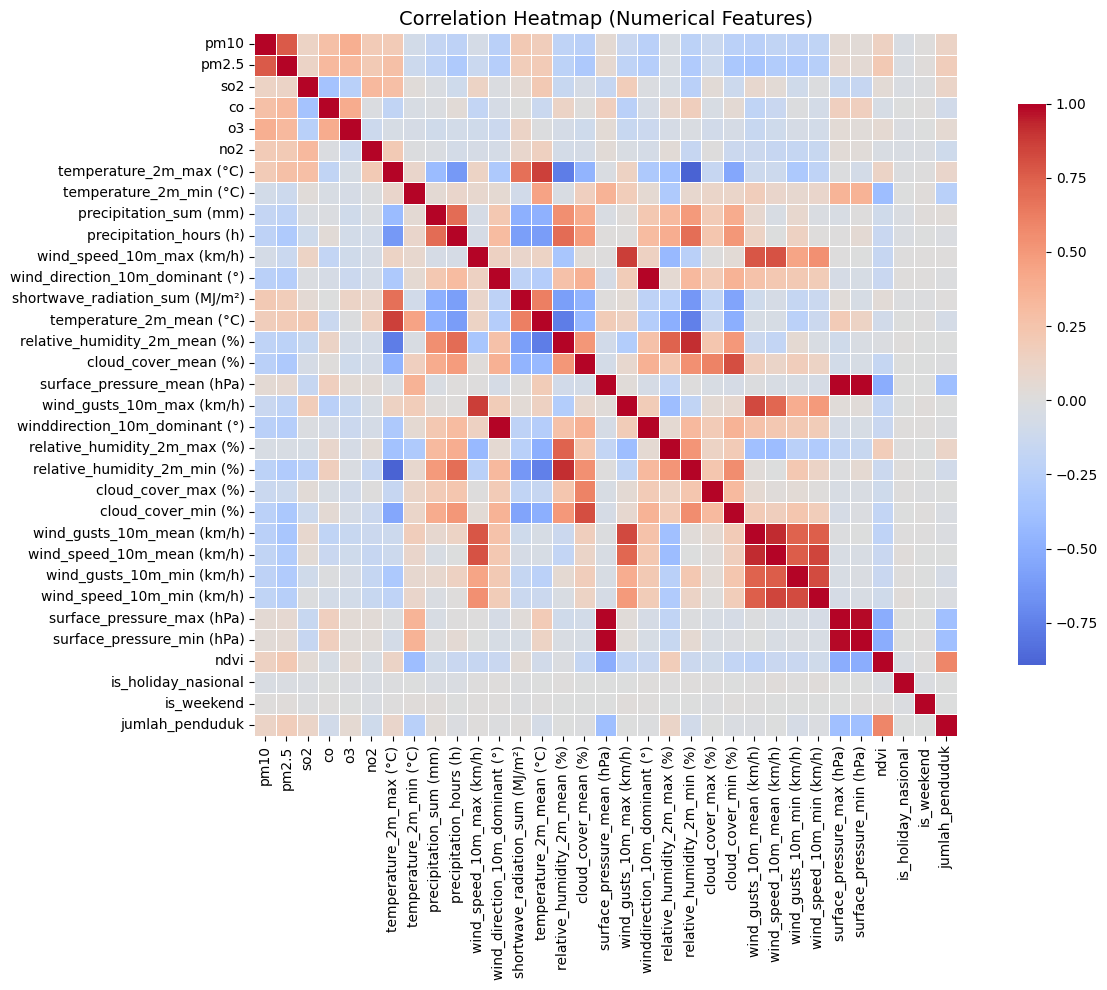

In [133]:
plt.figure(figsize=(14, 10))
corr_matrix = df.select_dtypes(include=["int64", "float64"]).corr()

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Heatmap (Numerical Features)", fontsize=14)
plt.tight_layout()
plt.show()

In [134]:
df["kategori"] = df["kategori"].replace("TIDAK ADA DATA", np.nan)

df["kategori"].value_counts(dropna=False)

kategori
SEDANG                10446
TIDAK SEHAT            2421
BAIK                   2342
NaN                    1459
SANGAT TIDAK SEHAT      200
BERBAHAYA                 1
Name: count, dtype: int64

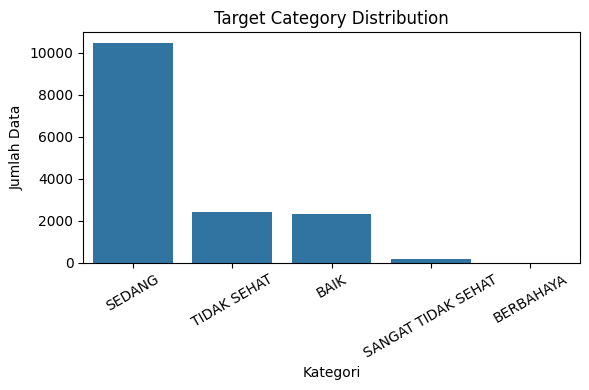

In [135]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x=target_col,
    order=df[target_col].value_counts().index
)

plt.title("Target Category Distribution")
plt.xlabel("Kategori")
plt.ylabel("Jumlah Data")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


Target encoding map:
{'BAIK': np.int64(0), 'BERBAHAYA': np.int64(1), 'SANGAT TIDAK SEHAT': np.int64(2), 'SEDANG': np.int64(3), 'TIDAK SEHAT': np.int64(4), nan: np.int64(5)}


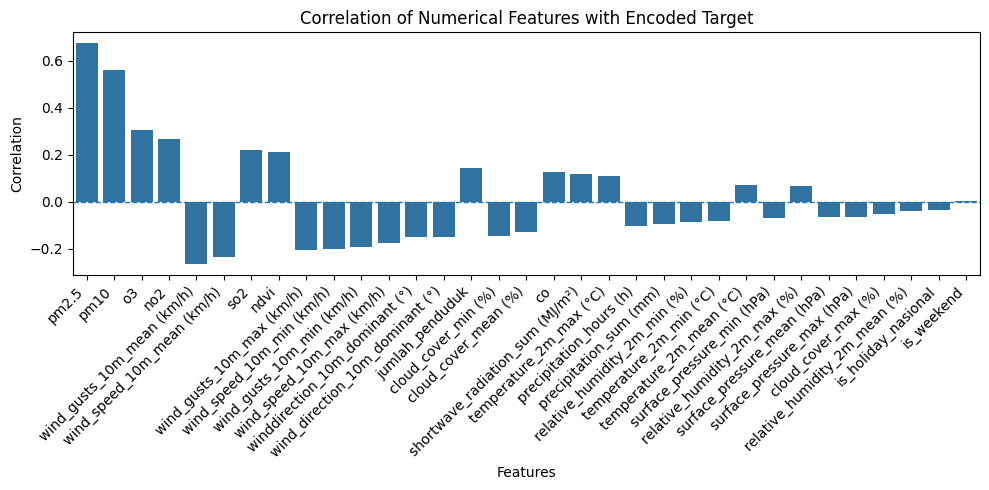

Top 15 features by correlation with target:
                            feature  correlation
0                             pm2.5     0.674420
1                              pm10     0.561609
2                                o3     0.305840
3                               no2     0.267818
4        wind_gusts_10m_mean (km/h)    -0.262922
5        wind_speed_10m_mean (km/h)    -0.235680
6                               so2     0.222577
7                              ndvi     0.212021
8         wind_gusts_10m_max (km/h)    -0.206014
9         wind_speed_10m_min (km/h)    -0.198940
10        wind_gusts_10m_min (km/h)    -0.190903
11        wind_speed_10m_max (km/h)    -0.175423
12   winddirection_10m_dominant (°)    -0.149151
13  wind_direction_10m_dominant (°)    -0.149151
14                  jumlah_penduduk     0.142765


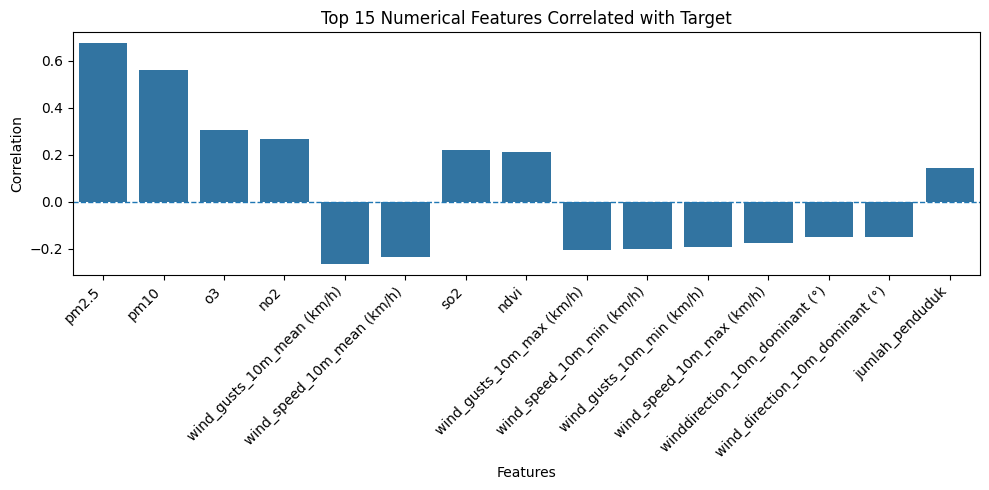

In [136]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["kategori_enc"] = le.fit_transform(df[target_col])

print("Target encoding map:")
print(dict(zip(le.classes_, le.transform(le.classes_))))

num_cols_valid = [c for c in num_cols if c in df.columns]
corr_target = (
    df[num_cols_valid]
    .corrwith(df["kategori_enc"])
    .sort_values(key=lambda x: x.abs(), ascending=False)
)

corr_df = corr_target.reset_index()
corr_df.columns = ["feature", "correlation"]

plt.figure(figsize=(10, 5))
sns.barplot(
    x=corr_df["feature"],
    y=corr_df["correlation"]
)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Correlation of Numerical Features with Encoded Target")
plt.ylabel("Correlation")
plt.xlabel("Features")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# --- Ambil top 15 fitur berdasarkan kekuatan korelasi ---
corr_df["abs_corr"] = corr_df["correlation"].abs()
top15_corr = corr_df.sort_values(by="abs_corr", ascending=False).head(15).drop(columns="abs_corr")

print("Top 15 features by correlation with target:")
print(top15_corr)

plt.figure(figsize=(10, 5))
sns.barplot(
    x="feature",
    y="correlation",
    data=top15_corr
)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Top 15 Numerical Features Correlated with Target")
plt.ylabel("Correlation")
plt.xlabel("Features")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


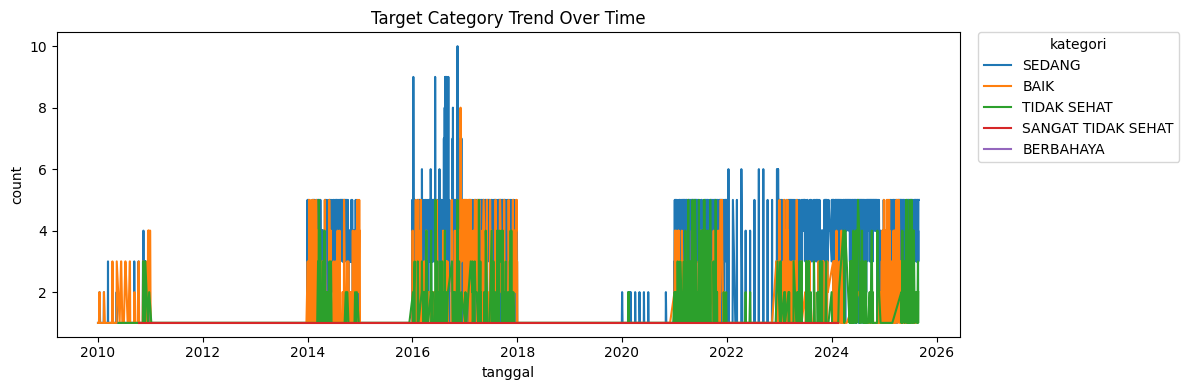

In [137]:
plt.figure(figsize=(12, 4))

target_time = (
    df
    .groupby([date_col, target_col])
    .size()
    .reset_index(name="count")
)

ax = sns.lineplot(
    data=target_time,
    x=date_col,
    y="count",
    hue=target_col
)

plt.title("Target Category Trend Over Time")

# pindahkan legend ke kanan luar
ax.legend(
    title=target_col,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

plt.tight_layout()
plt.show()

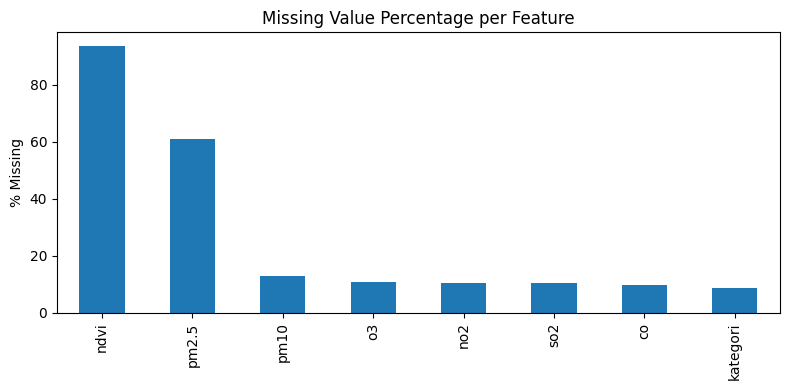

In [138]:
missing_pct = df.isna().mean().mul(100)
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

plt.figure(figsize=(8, 4))
missing_pct.plot(kind="bar")

plt.title("Missing Value Percentage per Feature")
plt.ylabel("% Missing")
plt.tight_layout()
plt.show()

# DATA PREPARATION AND CLEANING

In [139]:
print("Shape:", df.shape)
print("\nKolom:")
print(df.columns)

print("\nHead:")
df.head()

print("\nDescribe (numerik):")
df.describe()

Shape: (16869, 37)

Kolom:
Index(['tanggal', 'stasiun', 'pm10', 'pm2.5', 'so2', 'co', 'o3', 'no2',
       'temperature_2m_max (°C)', 'temperature_2m_min (°C)',
       'precipitation_sum (mm)', 'precipitation_hours (h)',
       'wind_speed_10m_max (km/h)', 'wind_direction_10m_dominant (°)',
       'shortwave_radiation_sum (MJ/m²)', 'temperature_2m_mean (°C)',
       'relative_humidity_2m_mean (%)', 'cloud_cover_mean (%)',
       'surface_pressure_mean (hPa)', 'wind_gusts_10m_max (km/h)',
       'winddirection_10m_dominant (°)', 'relative_humidity_2m_max (%)',
       'relative_humidity_2m_min (%)', 'cloud_cover_max (%)',
       'cloud_cover_min (%)', 'wind_gusts_10m_mean (km/h)',
       'wind_speed_10m_mean (km/h)', 'wind_gusts_10m_min (km/h)',
       'wind_speed_10m_min (km/h)', 'surface_pressure_max (hPa)',
       'surface_pressure_min (hPa)', 'ndvi', 'is_holiday_nasional',
       'is_weekend', 'jumlah_penduduk', 'kategori', 'kategori_enc'],
      dtype='object')

Head:

Describe (nume

,tanggal,pm10,pm2.5,so2,co,o3,no2,temperature_2m_max (°C),temperature_2m_min (°C),precipitation_sum (mm),...,wind_speed_10m_mean (km/h),wind_gusts_10m_min (km/h),wind_speed_10m_min (km/h),surface_pressure_max (hPa),surface_pressure_min (hPa),ndvi,is_holiday_nasional,is_weekend,jumlah_penduduk,kategori_enc
count,16869,14702.000000,6611.000000,15110.000000,15203.000000,15066.000000,15099.000000,16869.000000,16869.000000,16869.000000,...,16869.000000,16869.000000,16869.000000,16869.000000,16869.000000,1063.000000,16869.000000,16869.000000,1.686900e+04,16869.000000
mean,2018-07-26 01:30:29.130357248,54.098218,75.852216,27.907346,20.297178,53.443847,17.276310,30.655380,23.571142,6.991802,...,6.441864,6.836689,2.295020,1008.621934,1004.551509,0.345579,0.045587,0.285672,2.120610e+06,2.888019
min,2010-01-01 00:00:00,2.000000,10.000000,0.000000,0.000000,2.000000,0.000000,24.100000,18.600000,0.000000,...,2.200000,0.700000,0.000000,998.900000,995.400000,0.013800,0.000000,0.000000,9.066010e+05,0.000000
25%,2014-09-17 00:00:00,42.000000,60.000000,15.000000,11.000000,25.000000,10.000000,29.500000,23.000000,1.100000,...,4.800000,4.700000,1.000000,1006.700000,1002.600000,0.228150,0.000000,0.000000,1.764614e+06,3.000000
50%,2017-10-26 00:00:00,55.000000,77.000000,26.000000,18.000000,42.000000,15.000000,30.500000,23.600000,4.400000,...,5.800000,6.100000,1.800000,1009.400000,1005.300000,0.340500,0.000000,0.000000,2.232442e+06,3.000000
75%,2023-04-14 00:00:00,65.000000,91.000000,38.000000,26.000000,71.000000,22.000000,31.800000,24.100000,10.200000,...,7.400000,7.900000,2.900000,1011.000000,1006.900000,0.469200,0.000000,1.000000,2.528065e+06,3.000000
max,2025-08-31 00:00:00,187.000000,287.000000,112.000000,134.000000,314.000000,202.000000,38.800000,26.400000,116.100000,...,22.500000,36.000000,18.900000,1015.400000,1011.700000,0.752100,1.000000,1.000000,3.079618e+06,5.000000
std,NaN,18.952786,24.138489,15.588834,12.187505,40.567872,11.559528,1.844864,0.859245,8.279029,...,2.399150,3.413126,1.994611,3.095853,3.070620,0.146919,0.208593,0.451747,6.566260e+05,1.318577


In [140]:
df = df.drop_duplicates(subset=["tanggal", "stasiun"])
dup_rows = df.duplicated(subset=[entity_col, date_col]).sum()
print("Jumlah duplikasi (entitas + tanggal):", dup_rows)

Jumlah duplikasi (entitas + tanggal): 0


In [141]:
df = df[df["tanggal"].dt.year != 2010]
df["tanggal"].dt.year.value_counts().sort_index()
df = df.sort_values(["tanggal", "stasiun"]).reset_index(drop=True)


In [142]:
df.head()

,tanggal,stasiun,pm10,pm2.5,so2,co,o3,no2,temperature_2m_max (°C),temperature_2m_min (°C),...,wind_gusts_10m_min (km/h),wind_speed_10m_min (km/h),surface_pressure_max (hPa),surface_pressure_min (hPa),ndvi,is_holiday_nasional,is_weekend,jumlah_penduduk,kategori,kategori_enc
0,2011-01-01,DKI3,52.0,NaN,17.0,51.0,76.0,7.0,29.6,23.8,...,11.9,5.7,999.6,995.6,0.2657,1,1,2141941.0,SEDANG,3
1,2011-01-02,DKI4,56.0,NaN,20.0,22.0,29.0,11.0,30.0,24.1,...,11.5,4.5,1004.9,1000.9,NaN,0,1,2791072.0,SEDANG,3
2,2011-01-03,DKI2,40.0,NaN,14.0,26.0,42.0,8.0,28.0,24.5,...,12.6,5.4,1008.4,1005.3,NaN,0,0,1711036.0,BAIK,0
3,2011-01-04,DKI4,45.0,NaN,14.0,20.0,21.0,8.0,28.4,23.4,...,9.7,5.4,1004.6,1001.0,NaN,0,0,2791072.0,BAIK,0
4,2011-01-05,DKI1,71.0,NaN,18.0,54.0,88.0,31.0,28.0,23.7,...,6.5,1.1,1007.7,1004.3,NaN,0,0,906601.0,SEDANG,3


Interpolasi

In [143]:
cols_interp = ["pm10", "so2", "co", "o3", "no2"]

df["tanggal"] = pd.to_datetime(df["tanggal"])

df = df.sort_values(["stasiun", "tanggal"])

def interpolate_station(x):
    x = x.set_index("tanggal")
    x[cols_interp] = x[cols_interp].interpolate(method="time", limit_direction="both")
    if "ndvi" in x.columns:
        x["ndvi"] = x["ndvi"].interpolate(method="nearest", limit_direction="both")
    return x.reset_index()

df = df.groupby("stasiun", group_keys=False).apply(interpolate_station).reset_index(drop=True)

C:\Users\rovan wardana\AppData\Local\Temp\ipykernel_27024\1029518982.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("stasiun", group_keys=False).apply(interpolate_station).reset_index(drop=True)


In [144]:
df["pm2.5"] = df["pm2.5"].fillna(df["pm10"] * 1.5)

In [145]:
df = df.dropna(subset=["kategori"])

In [146]:
df = df.sort_values(["tanggal", "stasiun"]).reset_index(drop=True)
df.head()

,tanggal,stasiun,pm10,pm2.5,so2,co,o3,no2,temperature_2m_max (°C),temperature_2m_min (°C),...,wind_gusts_10m_min (km/h),wind_speed_10m_min (km/h),surface_pressure_max (hPa),surface_pressure_min (hPa),ndvi,is_holiday_nasional,is_weekend,jumlah_penduduk,kategori,kategori_enc
0,2011-01-01,DKI3,52.0,78.0,17.0,51.0,76.0,7.0,29.6,23.8,...,11.9,5.7,999.6,995.6,0.2657,1,1,2141941.0,SEDANG,3
1,2011-01-02,DKI4,56.0,84.0,20.0,22.0,29.0,11.0,30.0,24.1,...,11.5,4.5,1004.9,1000.9,NaN,0,1,2791072.0,SEDANG,3
2,2011-01-03,DKI2,40.0,60.0,14.0,26.0,42.0,8.0,28.0,24.5,...,12.6,5.4,1008.4,1005.3,NaN,0,0,1711036.0,BAIK,0
3,2011-01-04,DKI4,45.0,67.5,14.0,20.0,21.0,8.0,28.4,23.4,...,9.7,5.4,1004.6,1001.0,NaN,0,0,2791072.0,BAIK,0
4,2011-01-05,DKI1,71.0,106.5,18.0,54.0,88.0,31.0,28.0,23.7,...,6.5,1.1,1007.7,1004.3,NaN,0,0,906601.0,SEDANG,3


In [147]:
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14672 entries, 0 to 14671
Data columns (total 37 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   tanggal                          14672 non-null  datetime64[ns]
 1   stasiun                          14672 non-null  object        
 2   pm10                             14672 non-null  float64       
 3   pm2.5                            14672 non-null  float64       
 4   so2                              14672 non-null  float64       
 5   co                               14672 non-null  float64       
 6   o3                               14672 non-null  float64       
 7   no2                              14672 non-null  float64       
 8   temperature_2m_max (°C)          14672 non-null  float64       
 9   temperature_2m_min (°C)          14672 non-null  float64       
 10  precipitation_sum (mm)           14672 non-null  float64  

tanggal                             0
stasiun                             0
pm10                                0
pm2.5                               0
so2                                 0
co                                  0
o3                                  0
no2                                 0
temperature_2m_max (°C)             0
temperature_2m_min (°C)             0
precipitation_sum (mm)              0
precipitation_hours (h)             0
wind_speed_10m_max (km/h)           0
wind_direction_10m_dominant (°)     0
shortwave_radiation_sum (MJ/m²)     0
temperature_2m_mean (°C)            0
relative_humidity_2m_mean (%)       0
cloud_cover_mean (%)                0
surface_pressure_mean (hPa)         0
wind_gusts_10m_max (km/h)           0
winddirection_10m_dominant (°)      0
relative_humidity_2m_max (%)        0
relative_humidity_2m_min (%)        0
cloud_cover_max (%)                 0
cloud_cover_min (%)                 0
wind_gusts_10m_mean (km/h)          0
wind_speed_1

In [148]:
from sklearn.preprocessing import StandardScaler

df = df.sort_values(["stasiun", "tanggal"]).reset_index(drop=True)

pollutant_cols = ["pm10", "pm2.5", "so2", "no2", "o3", "co"]
binary_cols = ["is_weekend", "is_holiday_nasional"]
target_col_enc = "kategori_enc"
exclude_cols = binary_cols + [target_col_enc, "jumlah_penduduk"]

for col in pollutant_cols:
    df[f"{col}_lag3"] = df.groupby("stasiun")[col].shift(3)

df = (
    df.groupby("stasiun", group_keys=False)
      .apply(lambda x: x.iloc[3:])
      .reset_index(drop=True)
)

numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in exclude_cols]

scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])


C:\Users\rovan wardana\AppData\Local\Temp\ipykernel_27024\3910425470.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.iloc[3:])


In [149]:
df = df.sort_values(["stasiun", "tanggal"]).reset_index(drop=True)
df.head()

,tanggal,stasiun,pm10,pm2.5,so2,co,o3,no2,temperature_2m_max (°C),temperature_2m_min (°C),...,is_weekend,jumlah_penduduk,kategori,kategori_enc,pm10_lag3,pm2.5_lag3,so2_lag3,no2_lag3,o3_lag3,co_lag3
0,2011-03-01,DKI1,-0.678907,-0.648169,-0.807897,1.266678,-0.551458,-0.191956,-2.148138,-0.324763,...,0,906601.0,BAIK,0,0.887629,0.915262,-0.677499,1.176459,0.849641,2.849341
1,2011-03-05,DKI1,0.783931,0.812144,-0.420017,0.932444,0.383739,0.918339,-1.560585,0.366201,...,1,906601.0,SEDANG,3,-0.262008,-0.231841,-0.806794,-0.105532,-0.232758,0.512227
2,2011-04-22,DKI1,0.627198,0.655682,-0.807897,0.514650,1.761925,0.405895,-0.385479,-1.015727,...,0,906601.0,TIDAK SEHAT,4,-0.993595,-0.961815,-0.871441,-0.532862,-0.158958,-0.405925
3,2011-04-24,DKI1,0.522710,0.551374,-0.872544,0.598209,0.728286,-0.106549,-1.667413,0.481362,...,1,906601.0,SEDANG,3,-0.680058,-0.648969,-0.806794,-0.190998,-0.552558,1.263442
4,2011-04-25,DKI1,0.574954,0.603528,-0.743251,1.600913,0.408350,-0.106549,-1.133274,0.020719,...,0,906601.0,SEDANG,3,0.783117,0.810980,-0.418910,0.920061,0.382241,0.929568


# LSTM

In [152]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.optimizers import Adam

# ==========================
# 0. Seed untuk reproducibility
# ==========================
SEED = 42
np.random.seed(SEED)
import tensorflow as tf
tf.random.set_seed(SEED)

# ==========================
# 1. Tentukan top 15 feature + lag3
# ==========================
top15_features = top15_corr["feature"].tolist()

# ambil semua lag3 dari top15_features jika ada di df
lag3_features = [f"{f}_lag3" for f in top15_features if f"{f}_lag3" in df.columns]

# gabungkan top15 + lag3 (TANPA lag target dulu)
feature_cols = top15_features + lag3_features

# simpan kolom target
target_col_enc = "kategori_enc"

print(f"Total features to forecast: {len(feature_cols)}")
print(f"Features: {feature_cols[:5]}... (showing first 5)")

# ==========================
# 2. STEP 1: Build Feature Forecasting Model
# ==========================
print("\n" + "="*60)
print("STEP 1: Training Feature Forecasting Model")
print("="*60)

SEQ_LEN = 7  # gunakan sequence lebih panjang untuk forecast fitur
FORECAST_HORIZON = 1  # forecast 1 step ahead

# Prepare data untuk feature forecasting
X_feat_seq, y_feat_seq = [], []

for st in df["stasiun"].unique():
    st_data = df[df["stasiun"] == st].sort_values("tanggal")
    feature_data = st_data[feature_cols].values
    
    for i in range(SEQ_LEN, len(st_data)):
        # X: sequence of features
        X_feat_seq.append(feature_data[i-SEQ_LEN:i])
        # y: next step features (all features)
        y_feat_seq.append(feature_data[i])

X_feat_seq = np.array(X_feat_seq)
y_feat_seq = np.array(y_feat_seq)

print(f"Feature forecast data shape: X={X_feat_seq.shape}, y={y_feat_seq.shape}")

# Split train/val for feature forecasting
split_idx_feat = int(len(X_feat_seq) * 0.9)
X_feat_train = X_feat_seq[:split_idx_feat]
y_feat_train = y_feat_seq[:split_idx_feat]
X_feat_val = X_feat_seq[split_idx_feat:]
y_feat_val = y_feat_seq[split_idx_feat:]

# Build feature forecasting model (multi-output)
feature_model = Sequential([
    LSTM(128, input_shape=(SEQ_LEN, len(feature_cols)), return_sequences=True),
    Dropout(0.3),
    BatchNormalization(),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(len(feature_cols))  # output = semua fitur
])

feature_model.compile(
    loss="mse",
    optimizer=Adam(learning_rate=0.001),
    metrics=["mae"]
)

print("\nTraining feature forecasting model...")
early_stop_feat = EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)

history_feat = feature_model.fit(
    X_feat_train, y_feat_train,
    validation_data=(X_feat_val, y_feat_val),
    epochs=100,
    batch_size=64,
    callbacks=[early_stop_feat],
    verbose=2
)

print("✓ Feature forecasting model trained!")

# ==========================
# 3. STEP 2: Build Target Classification Model
# ==========================
print("\n" + "="*60)
print("STEP 2: Training Target Classification Model")
print("="*60)

SEQ_LEN_TARGET = 3  # sequence untuk target model
X_target_seq, y_target_seq = [], []

for st in df["stasiun"].unique():
    st_data = df[df["stasiun"] == st].sort_values("tanggal")
    feature_data = st_data[feature_cols].values
    target_data = st_data[target_col_enc].values
    
    for i in range(SEQ_LEN_TARGET, len(st_data)):
        if pd.isna(target_data[i]):
            continue
        X_target_seq.append(feature_data[i-SEQ_LEN_TARGET:i])
        y_target_seq.append(target_data[i])

X_target_seq = np.array(X_target_seq)
y_target_seq = np.array(y_target_seq)
num_classes = int(y_target_seq.max() + 1)

print(f"Target classification data shape: X={X_target_seq.shape}, y={y_target_seq.shape}")
print(f"Number of classes: {num_classes}")

# Hitung class weight
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_target_seq),
    y=y_target_seq
)
class_weight_dict = dict(enumerate(class_weights))
print(f"Class weights: {class_weight_dict}")

# Split train/val
split_idx_target = int(len(X_target_seq) * 0.9)
X_target_train = X_target_seq[:split_idx_target]
y_target_train = y_target_seq[:split_idx_target]
X_target_val = X_target_seq[split_idx_target:]
y_target_val = y_target_seq[split_idx_target:]

# Build target classification model
target_model = Sequential([
    LSTM(128, input_shape=(SEQ_LEN_TARGET, len(feature_cols)), return_sequences=True),
    Dropout(0.3),
    BatchNormalization(),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(num_classes, activation="softmax")
])

target_model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=Adam(learning_rate=0.001),
    metrics=["accuracy"]
)

print("\nTraining target classification model...")
early_stop_target = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

history_target = target_model.fit(
    X_target_train, y_target_train,
    validation_data=(X_target_val, y_target_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop_target],
    class_weight=class_weight_dict,
    verbose=2
)

# Evaluasi target model
y_pred_val = np.argmax(target_model.predict(X_target_val), axis=1)
macro_f1 = f1_score(y_target_val, y_pred_val, average="macro")
print(f"\n✓ Target model trained!")
print(f"Validation Macro F1 Score: {macro_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_target_val, y_pred_val))

# Confusion Matrix
cm = confusion_matrix(y_target_val, y_pred_val)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Validation Set")
plt.close()
print("✓ Confusion matrix saved!")

# ==========================
# 4. STEP 3: Forecast Features for Test Period
# ==========================
print("\n" + "="*60)
print("STEP 3: Forecasting Features for Test Period")
print("="*60)

test_dates = pd.date_range("2025-09-01", "2025-11-30", freq="D")
num_forecast_days = len(test_dates)
print(f"Forecasting {num_forecast_days} days for each station...")

stasiun_list = sorted(df["stasiun"].unique(), key=lambda x: int(x.upper().replace("DKI","")))

# Dictionary untuk menyimpan forecasted features per stasiun
forecasted_features = {}

for st in stasiun_list:
    print(f"\nForecasting features for {st}...")
    st_data = df[df["stasiun"] == st].sort_values("tanggal")
    
    # Ambil SEQ_LEN terakhir sebagai starting point
    last_seq = st_data[feature_cols].values[-SEQ_LEN:].copy()
    
    # Forecast iteratively
    forecasted_feat_list = []
    
    for day_idx in range(num_forecast_days):
        # Predict next day features
        X_input = last_seq[np.newaxis, :, :]
        next_feat = feature_model.predict(X_input, verbose=0)[0]
        
        forecasted_feat_list.append(next_feat)
        
        # Update sequence
        last_seq = np.vstack([last_seq[1:], next_feat])
    
    # Simpan hasil forecast
    forecasted_features[st] = np.array(forecasted_feat_list)
    print(f"  ✓ Forecasted {len(forecasted_feat_list)} days")

print("\n✓ All features forecasted for test period!")

# ==========================
# 5. STEP 4: Predict Target using Forecasted Features
# ==========================
print("\n" + "="*60)
print("STEP 4: Predicting Target using Forecasted Features")
print("="*60)

submission_rows = []

for st in stasiun_list:
    print(f"\nPredicting target for {st}...")
    
    # Ambil forecasted features untuk stasiun ini
    feat_forecast = forecasted_features[st]  # shape: (num_forecast_days, num_features)
    
    # Untuk prediksi pertama, kita perlu SEQ_LEN_TARGET dari historical data
    st_data = df[df["stasiun"] == st].sort_values("tanggal")
    historical_feat = st_data[feature_cols].values[-(SEQ_LEN_TARGET-1):].copy()
    
    # Gabungkan historical + forecasted untuk sliding window
    all_features = np.vstack([historical_feat, feat_forecast])
    
    # Predict target untuk setiap hari
    for day_idx, d in enumerate(test_dates):
        # Ambil sequence SEQ_LEN_TARGET
        start_idx = day_idx
        end_idx = day_idx + SEQ_LEN_TARGET
        X_input = all_features[start_idx:end_idx][np.newaxis, :, :]
        
        # Predict
        y_pred_enc = np.argmax(target_model.predict(X_input, verbose=0), axis=1)[0]
        y_pred_label = le.inverse_transform([y_pred_enc])[0]
        
        submission_rows.append({
            "id": f"{d.strftime('%Y-%m-%d')}_{st}",
            "kategori": y_pred_label
        })
    
    print(f"  ✓ Predicted {len(test_dates)} days")

# ==========================
# 6. Create Submission File
# ==========================
print("\n" + "="*60)
print("Creating Submission File")
print("="*60)

submission_lstm = pd.DataFrame(submission_rows)
submission_lstm["stasiun_num"] = submission_lstm["id"].str.extract(r"(?i)dki(\d+)")[0].astype(int)
submission_lstm = submission_lstm.sort_values(["id", "stasiun_num"]).reset_index(drop=True)
submission_lstm = submission_lstm.drop(columns="stasiun_num")

# Save to outputs directory
output_path = "submission_lstm_5.csv"
submission_lstm.to_csv(output_path, index=False)

print(f"\n✓ Submission file saved: {output_path}")
print(f"Total predictions: {len(submission_lstm)}")
print(f"\nFirst few rows:")
print(submission_lstm.head(10))
print(f"\nKategori distribution:")
print(submission_lstm["kategori"].value_counts().sort_index())


Total features to forecast: 20
Features: ['pm2.5', 'pm10', 'o3', 'no2', 'wind_gusts_10m_mean (km/h)']... (showing first 5)

STEP 1: Training Feature Forecasting Model
Feature forecast data shape: X=(14617, 7, 20), y=(14617, 20)

Training feature forecasting model...
Epoch 1/100


c:\Miniconda3\envs\ml\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


206/206 - 7s - 35ms/step - loss: nan - mae: nan - val_loss: nan - val_mae: nan
Epoch 2/100
206/206 - 3s - 15ms/step - loss: nan - mae: nan - val_loss: nan - val_mae: nan
Epoch 3/100
206/206 - 6s - 27ms/step - loss: nan - mae: nan - val_loss: nan - val_mae: nan
Epoch 4/100
206/206 - 3s - 17ms/step - loss: nan - mae: nan - val_loss: nan - val_mae: nan
Epoch 5/100
206/206 - 3s - 13ms/step - loss: nan - mae: nan - val_loss: nan - val_mae: nan
Epoch 6/100
206/206 - 3s - 12ms/step - loss: nan - mae: nan - val_loss: nan - val_mae: nan
Epoch 7/100
206/206 - 3s - 17ms/step - loss: nan - mae: nan - val_loss: nan - val_mae: nan
Epoch 8/100
206/206 - 3s - 15ms/step - loss: nan - mae: nan - val_loss: nan - val_mae: nan
Epoch 9/100
206/206 - 3s - 12ms/step - loss: nan - mae: nan - val_loss: nan - val_mae: nan
Epoch 10/100
206/206 - 3s - 13ms/step - loss: nan - mae: nan - val_loss: nan - val_mae: nan
Epoch 11/100
206/206 - 2s - 12ms/step - loss: nan - mae: nan - val_loss: nan - val_mae: nan
Epoch 12/

c:\Miniconda3\envs\ml\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


412/412 - 8s - 19ms/step - accuracy: 0.5480 - loss: 1.7114 - val_accuracy: 0.6837 - val_loss: 1.5353
Epoch 2/50
412/412 - 2s - 6ms/step - accuracy: 0.6819 - loss: 1.6949 - val_accuracy: 0.6837 - val_loss: 1.5398
Epoch 3/50
412/412 - 3s - 6ms/step - accuracy: 0.6819 - loss: 1.6940 - val_accuracy: 0.6837 - val_loss: 1.5443
Epoch 4/50
412/412 - 3s - 7ms/step - accuracy: 0.5328 - loss: 1.6932 - val_accuracy: 0.1270 - val_loss: 1.5485
Epoch 5/50
412/412 - 3s - 6ms/step - accuracy: 0.1644 - loss: 1.6924 - val_accuracy: 0.1270 - val_loss: 1.5526
Epoch 6/50
412/412 - 3s - 6ms/step - accuracy: 0.1013 - loss: 1.6917 - val_accuracy: 0.0000e+00 - val_loss: 1.5564
Epoch 7/50
412/412 - 3s - 7ms/step - accuracy: 0.0149 - loss: 1.6910 - val_accuracy: 0.0000e+00 - val_loss: 1.5601
Epoch 8/50
412/412 - 3s - 6ms/step - accuracy: 0.0149 - loss: 1.6904 - val_accuracy: 0.0000e+00 - val_loss: 1.5635
Epoch 9/50
412/412 - 3s - 6ms/step - accuracy: 0.0149 - loss: 1.6898 - val_accuracy: 0.0000e+00 - val_loss: 1.

c:\Miniconda3\envs\ml\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Miniconda3\envs\ml\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Miniconda3\envs\ml\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


  ✓ Forecasted 91 days

Forecasting features for DKI2...
  ✓ Forecasted 91 days

Forecasting features for DKI3...
  ✓ Forecasted 91 days

Forecasting features for DKI4...
  ✓ Forecasted 91 days

Forecasting features for DKI5...
  ✓ Forecasted 91 days

✓ All features forecasted for test period!

STEP 4: Predicting Target using Forecasted Features

Predicting target for DKI1...
  ✓ Predicted 91 days

Predicting target for DKI2...
  ✓ Predicted 91 days

Predicting target for DKI3...
  ✓ Predicted 91 days

Predicting target for DKI4...
  ✓ Predicted 91 days

Predicting target for DKI5...
  ✓ Predicted 91 days

Creating Submission File

✓ Submission file saved: submission_lstm_5.csv
Total predictions: 455

First few rows:
                id kategori
0  2025-09-01_DKI1   SEDANG
1  2025-09-01_DKI2   SEDANG
2  2025-09-01_DKI3   SEDANG
3  2025-09-01_DKI4   SEDANG
4  2025-09-01_DKI5   SEDANG
5  2025-09-02_DKI1   SEDANG
6  2025-09-02_DKI2   SEDANG
7  2025-09-02_DKI3   SEDANG
8  2025-09-02_DKI4   